<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Homeworks/Homework_6_INFO_648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  PART 1


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/churn_synthetic_600_new.csv')

In [3]:
df.head()

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,23,77.81,Month-to-Month,Credit Card,1
1,C0002,0,33,69.65,One-Year,Credit Card,1
2,C0003,1,22,64.27,Month-to-Month,Electronic Check,2
3,C0004,1,4,66.30,Month-to-Month,Credit Card,3
4,C0005,0,2,60.82,One-Year,Bank Transfer,1


In [4]:
df.describe()

,Churn,TenureMonths,MonthlyCharge,SupportCalls
count,600.000000,600.000000,600.000000,600.000000
mean,0.176667,37.270000,71.661650,1.293333
std,0.381705,20.340189,20.113612,1.061052
min,0.000000,1.000000,25.000000,0.000000
25%,0.000000,21.000000,58.147500,0.000000
50%,0.000000,37.000000,71.350000,1.000000
75%,0.000000,54.000000,84.717500,2.000000
max,1.000000,72.000000,134.620000,6.000000


In [10]:
# "TenureMonths", "MonthlyCharge", "SupportCalls", "ContractType", "PaymentMethod"
numeric_features = ["TenureMonths", "MonthlyCharge", "SupportCalls"]
categorical_features = ["ContractType", "PaymentMethod"]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
Categorical: ['ContractType', 'PaymentMethod']


In [6]:
#Preprocessing Pipeline with one hot encoding

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

We still use preprocessing because we need all of the data to be handled the same way to prevent data leakage. This also allows for the categorical data to be turned into numbers that can be modeled easier.

## PART 2

In [16]:
model_df=df.copy()

In [17]:
from sklearn.model_selection import train_test_split
X = model_df[["TenureMonths", "MonthlyCharge", "SupportCalls", "ContractType", "PaymentMethod"]]
y = model_df["Churn"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

model = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(max_depth=12, min_samples_leaf=18, random_state=42))
])

In [22]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=12, min_samples_leaf=18,
                                        random_state=42))])

Log regression uses a weighted sum to produce probabilities and assumes data is linear while a decision tree learns from yes no rules in the training data that can be non-linear relationships.

##PART 3

In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[118   6]
 [ 19   7]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       124
           1       0.54      0.27      0.36        26

    accuracy                           0.83       150
   macro avg       0.70      0.61      0.63       150
weighted avg       0.81      0.83      0.81       150



**Confusion Matrix:**

|  | Predicted: No Churn (0) | Predicted: Churn (1) |
|---|---|---|
| **Actual: No Churn (0)** | 118 | 6 |
| **Actual: Churn (1)** | 19 | 7 |


Accuracy is 0.83 meaning the model correctly labeled 83% of customers overall.

Precision is 0.54 so when the model predicted churn, it was only correct 54%
of the time. This also tells us we had a good amount of false alarms

Recall is 0.27 so the model only caught 27% churners, which is missing 19 out of 26 real churners.

Overall the recall is a concern since they are missing about 19/26 churners. With people walking out the door they would be losing more people than they are keeping from the customers they think are leaving already. Based on the confusuon matrix they have a a skewed amount as no churn which tells me the accuracy is also most likely skewed, so the .5 threshold is not greatly helpful.

## PART 4

In [30]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

np.float64(0.7361972704714641)

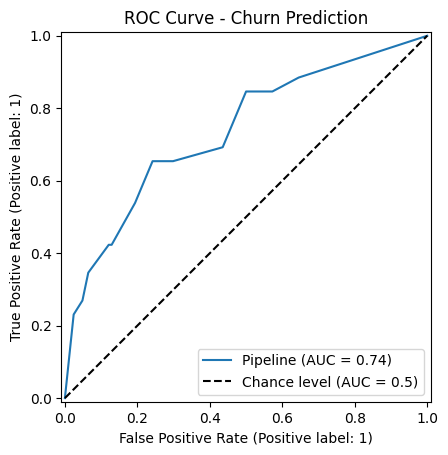

In [31]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test, plot_chance_level=True)
plt.title('ROC Curve - Churn Prediction')
plt.show()

1. What does the ROC curve represent in a classification model?
  
    A ROC curve shows TPR against FPR for every threshold.

2. What does the Area Under the Curve (AUC) measure?
  
    It shows the models ability to predict a random churner higher than a non churner seperate from the given threshold.

3. What does the AUC for this model tell us??
  
    This model has a roc score of .74 which means there is a 74% chance the model predicts a churner higher than a non churner.

4. What would an AUC value close to 1.00 imply?
  
    A 1 AUC would mean the model is perfectly spliting the churners from non churners.

5. Why is ROC analysis useful when classification thresholds can change?
  
    Roc analysis is good because the standard 0.5 is not always best and a Roc curve lets us see the performance for different thresholds.

##PART 5

In [32]:
# Part 5 - Youden's J Threshold Optimization

from sklearn.metrics import roc_curve

# Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Compute TPR and FPR across all thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute Youden's J statistic
J = tpr - fpr

# Find the optimal threshold
optimal_idx = J.argmax()
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_J = J[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"TPR at Optimal:    {optimal_tpr:.4f}")
print(f"FPR at Optimal:    {optimal_fpr:.4f}")
print(f"Youden's J:        {optimal_J:.4f}")

Optimal Threshold: 0.2222
TPR at Optimal:    0.6538
FPR at Optimal:    0.2419
Youden's J:        0.4119


Prompt:

Please give me python that computes (J = TPR - FPR) using sklearn's roc curve and identifies the optimal threshold by maximizing Youden's J statistic.

Add the print code for optimal threshold, TPR, FPR, and J value.



Youden's J maximizes TPR minus FPR, finding the threshold that
best balances catching churners vs false alarms. In this model, the optimal
threshold of 0.2222 achieved a TPR of 0.6538 and a J of 0.4119, catching more than the default, which only had a .27 recall.

##PART 6

In [34]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal, digits=3))

[[94 30]
 [ 9 17]]
              precision    recall  f1-score   support

           0      0.913     0.758     0.828       124
           1      0.362     0.654     0.466        26

    accuracy                          0.740       150
   macro avg      0.637     0.706     0.647       150
weighted avg      0.817     0.740     0.765       150



**Confusion Matrix:**

|  | Predicted: No Churn (0) | Predicted: Churn (1) |
|---|---|---|
| **Actual: No Churn (0)** | 94 | 30 |
| **Actual: Churn (1)** | 9 | 17 |

1.   Which metric improved the most?

      Recall was the most imporved jumping from .27 to .65.

2.   Did any metric decrease?
    
       Precision decreased from .54 to .36 and accuracy dropped some from .83 to .74.

3.   Which threshold would you deploy in practice?
    
      I would use the optimal threshold because if you lose a customer that could be more impactful than the precision and accuracy being a little lower.
